# Análise | Venda de móveis

# Importando os módulos.

In [164]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
plt.style.use('fivethirtyeight')
import pandas as pd
import statsmodels.api as sm
import matplotlib
import warnings
warnings.filterwarnings('ignore')
matplotlib.rcParams['axes.labelsize'] = 14
matplotlib.rcParams['xtick.labelsize'] = 12
matplotlib.rcParams['ytick.labelsize'] = 12
matplotlib.rcParams['text.color'] = 'k'

# Carregando os dados.

In [165]:
df = pd.read_excel("D:/Github/portfolio/ciencia-de-dados/furniture-sale/superstore.xls")
furniture = df.loc[df['Category'] == 'Furniture']

# Visualizando dados.

In [167]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Verificando os tipos dos dados.

In [169]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [170]:
furniture['Order Date'].min(), furniture['Order Date'].max()

(Timestamp('2014-01-06 00:00:00'), Timestamp('2017-12-30 00:00:00'))

# Removendo colunas desnecessárias.

In [172]:
cols = ['Row ID', 'Order ID', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Quantity', 'Discount', 'Profit']
furniture.drop(cols, axis=1, inplace=True)
furniture = furniture.sort_values('Order Date')
furniture.isnull().sum()

Order Date    0
Sales         0
dtype: int64

In [173]:
furniture = furniture.groupby('Order Date')['Sales'].sum().reset_index()

# Indexação com dados de séries temporais.

In [175]:
furniture = furniture.set_index('Order Date')
furniture.index

DatetimeIndex(['2014-01-06', '2014-01-07', '2014-01-10', '2014-01-11',
               '2014-01-13', '2014-01-14', '2014-01-16', '2014-01-19',
               '2014-01-20', '2014-01-21',
               ...
               '2017-12-18', '2017-12-19', '2017-12-21', '2017-12-22',
               '2017-12-23', '2017-12-24', '2017-12-25', '2017-12-28',
               '2017-12-29', '2017-12-30'],
              dtype='datetime64[ns]', name='Order Date', length=889, freq=None)

### Valor médio de vendas diárias e o início de cada mês como carimbo de data/hora.

In [177]:
y = furniture['Sales'].resample('MS').mean()

# Selecionando dados de 2017.

In [179]:
y['2017':]

Order Date
2017-01-01     397.602133
2017-02-01     528.179800
2017-03-01     544.672240
2017-04-01     453.297905
2017-05-01     678.302328
2017-06-01     826.460291
2017-07-01     562.524857
2017-08-01     857.881889
2017-09-01    1209.508583
2017-10-01     875.362728
2017-11-01    1277.817759
2017-12-01    1256.298672
Freq: MS, Name: Sales, dtype: float64

# Dados de série temporal: vendas/móveis.

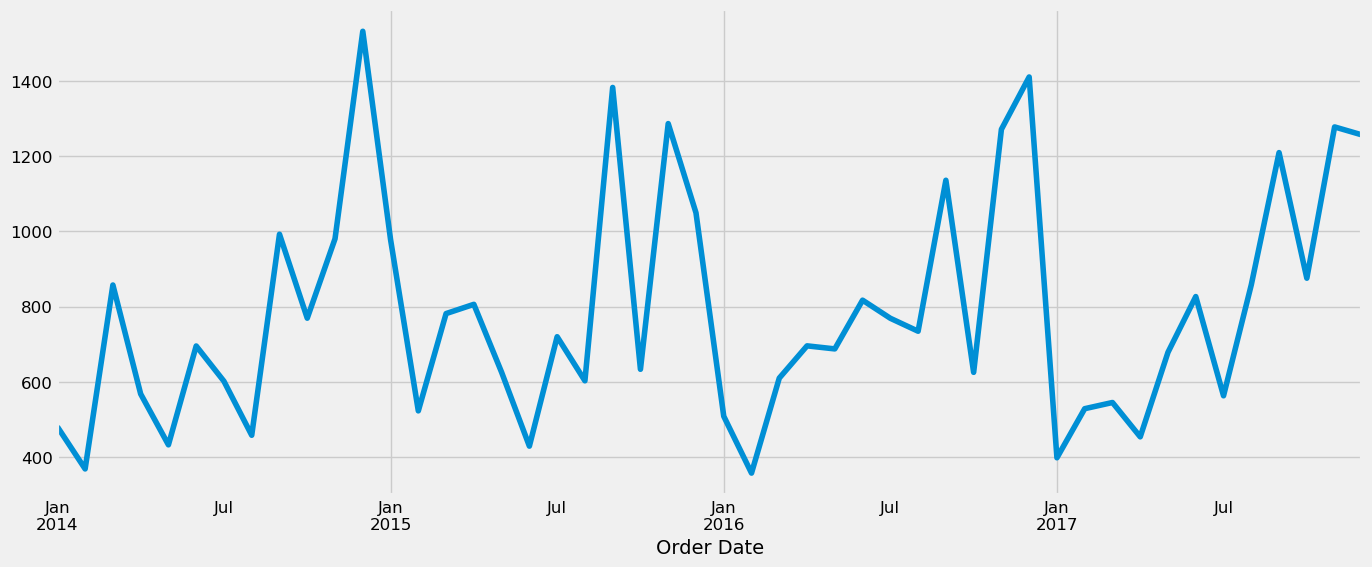

In [181]:
y.plot(figsize=(15, 6))
plt.show()

#### A série temporal possui padrão de sazonalidade, ou seja, as vendas são sempre baixas no início do ano e altas no final do ano. 

# Decompondo: tendência, sazonalidade e ruído.

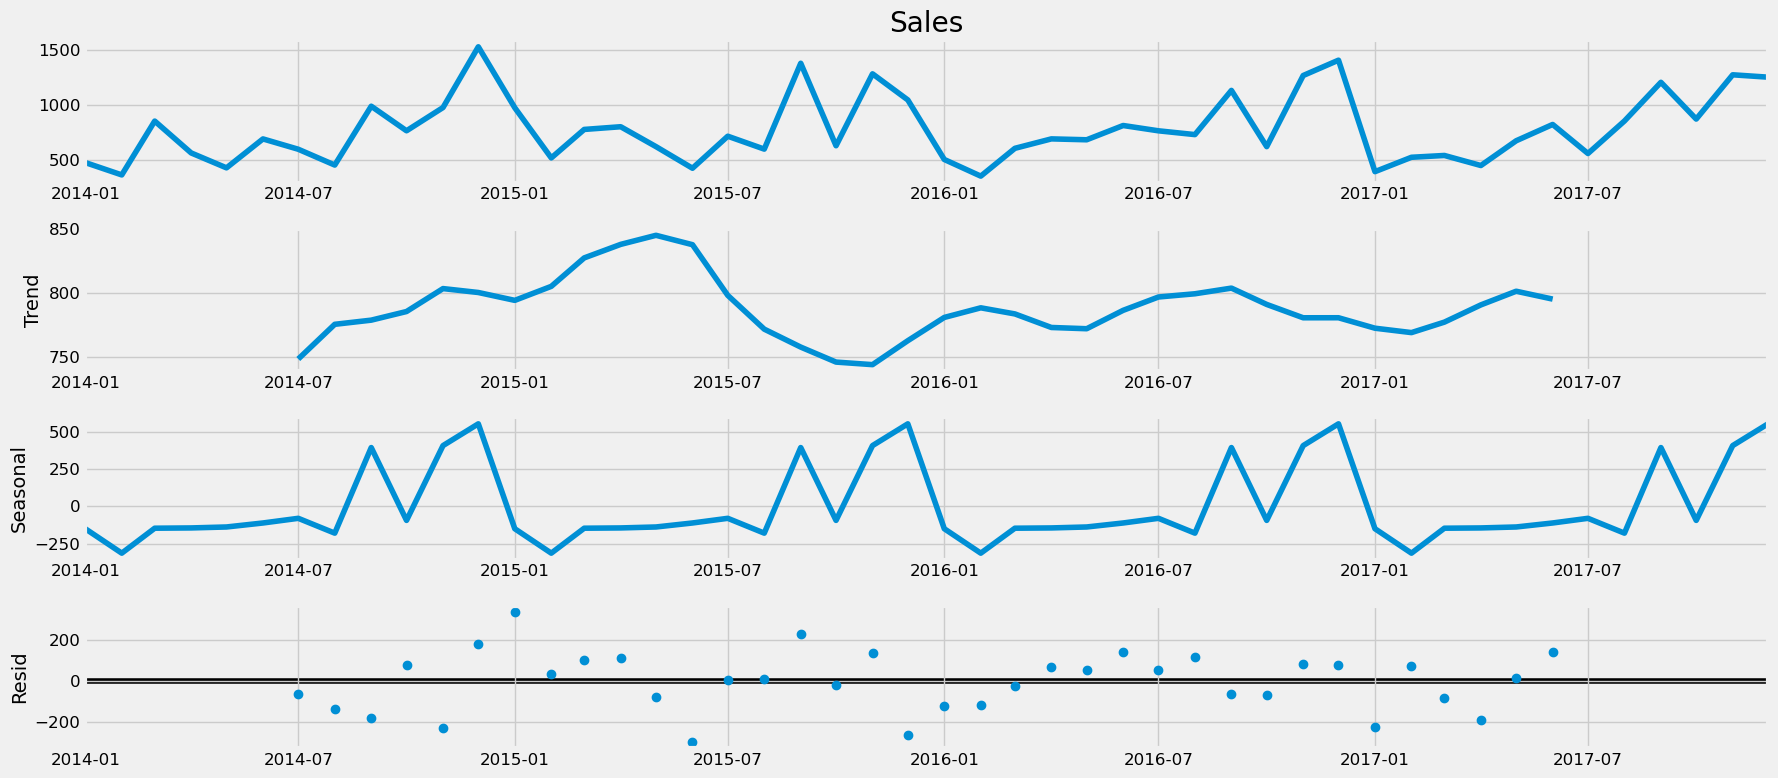

In [183]:
from pylab import rcParams
rcParams['figure.figsize'] = 18, 8
decomposition = sm.tsa.seasonal_decompose(y, model='additive')
fig = decomposition.plot()
plt.show()

#### O gráfico acima mostra claramente que as vendas de móveis são instáveis, com sua óbvia sazonalidade.

# Previsão de série temporal com ARIMA.

#### Vamos aplicar um dos métodos mais usados ​​para previsão de séries temporais, conhecido como ARIMA, que significa Autoregressive Integrated Moving Average.
#### Os modelos ARIMA são indicados com a notação ARIMA(p, d, q). Esses três parâmetros são responsáveis ​​pela sazonalidade, tendência e ruído nos dados:

In [186]:
p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]
print('Examples of parameter combinations for Seasonal ARIMA...')
print('SARIMAX: {} x {}'.format(pdq[1], seasonal_pdq[1]))
print('SARIMAX: {} x {}'.format(pdq[1], seasonal_pdq[2]))
print('SARIMAX: {} x {}'.format(pdq[2], seasonal_pdq[3]))
print('SARIMAX: {} x {}'.format(pdq[2], seasonal_pdq[4]))

Examples of parameter combinations for Seasonal ARIMA...
SARIMAX: (0, 0, 1) x (0, 0, 1, 12)
SARIMAX: (0, 0, 1) x (0, 1, 0, 12)
SARIMAX: (0, 1, 0) x (0, 1, 1, 12)
SARIMAX: (0, 1, 0) x (1, 0, 0, 12)


#### Esta etapa é a seleção de parâmetros para o modelo de série temporal ARIMA de vendas de móveis. 
#### Nosso objetivo aqui é usar uma “pesquisa de grade” para encontrar o conjunto ideal de parâmetros que produz o melhor desempenho para nosso modelo.

In [188]:
for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(
                 y,
                 order=param,
                 seasonal_order=param_seasonal,
                 enforce_invertibility=False
            )
            results = mod.fit()

            print('ARIMA{}x{}12 - AIC:{}'.format(
                 param,
                 param_seasonal,
                 results.aic
            ))
        except:
            continue

ARIMA(0, 0, 0)x(0, 0, 0, 12)12 - AIC:784.7193402038779
ARIMA(0, 0, 0)x(0, 0, 1, 12)12 - AIC:2172.484488531284
ARIMA(0, 0, 0)x(0, 1, 0, 12)12 - AIC:495.3709027489218
ARIMA(0, 0, 0)x(0, 1, 1, 12)12 - AIC:489.83053264642945
ARIMA(0, 0, 0)x(1, 0, 0, 12)12 - AIC:691.7786646550559
ARIMA(0, 0, 0)x(1, 0, 1, 12)12 - AIC:686.726724152219
ARIMA(0, 0, 0)x(1, 1, 0, 12)12 - AIC:491.25398194267945
ARIMA(0, 0, 0)x(1, 1, 1, 12)12 - AIC:491.8095630482044
ARIMA(0, 0, 1)x(0, 0, 0, 12)12 - AIC:751.0635462763071
ARIMA(0, 0, 1)x(0, 0, 1, 12)12 - AIC:2164.045666117372
ARIMA(0, 0, 1)x(0, 1, 0, 12)12 - AIC:497.0445558719427
ARIMA(0, 0, 1)x(0, 1, 1, 12)12 - AIC:491.664077128695
ARIMA(0, 0, 1)x(1, 0, 0, 12)12 - AIC:689.6572892688648
ARIMA(0, 0, 1)x(1, 0, 1, 12)12 - AIC:685.1459593030588
ARIMA(0, 0, 1)x(1, 1, 0, 12)12 - AIC:493.1979865785855
ARIMA(0, 0, 1)x(1, 1, 1, 12)12 - AIC:493.6293522352365
ARIMA(0, 1, 0)x(0, 0, 0, 12)12 - AIC:691.6686053888744
ARIMA(0, 1, 0)x(0, 0, 1, 12)12 - AIC:1997.0166031529657
ARIMA(0, 

#### A saída acima sugere que SARIMAX (0, 1, 1) x (0, 1, 1, 12) produz o menor valor AIC de 482,83. 
#### Portanto, devemos considerar que esta é a opção ideal.

In [189]:
mod = sm.tsa.statespace.SARIMAX(y,
                                order=(0, 1, 1),
                                seasonal_order=(0, 1, 1, 12),
                                enforce_invertibility=False)
results = mod.fit()
print(results.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -1.0000   1060.799     -0.001      0.999   -2080.129    2078.129
ma.S.L12      -1.0001   1060.865     -0.001      0.999   -2080.257    2078.257
sigma2      2.686e+04      0.002   1.56e+07      0.000    2.69e+04    2.69e+04


### Executar diagnóstico do modelo para investigar qualquer comportamento incomum.

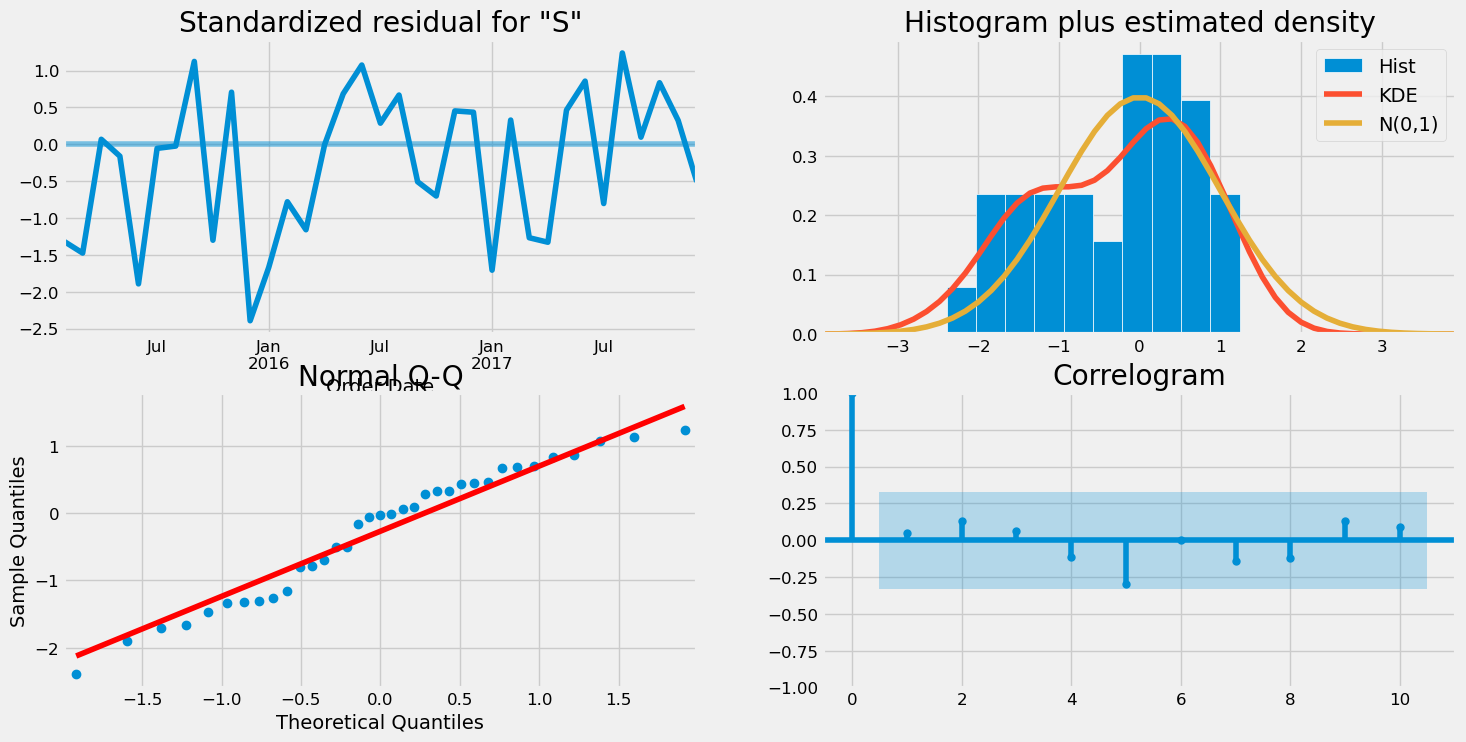

In [191]:
results.plot_diagnostics(figsize=(16, 8))
plt.show()

#### Nosso diagnóstico de modelo sugere que os resíduos do modelo são quase normalmente distribuídos.

# Validando previsões.

#### Compara as vendas previstas com as vendas reais da série temporal.
#### Definir as previsões para começar em 2017-01-01 até o final dos dados.

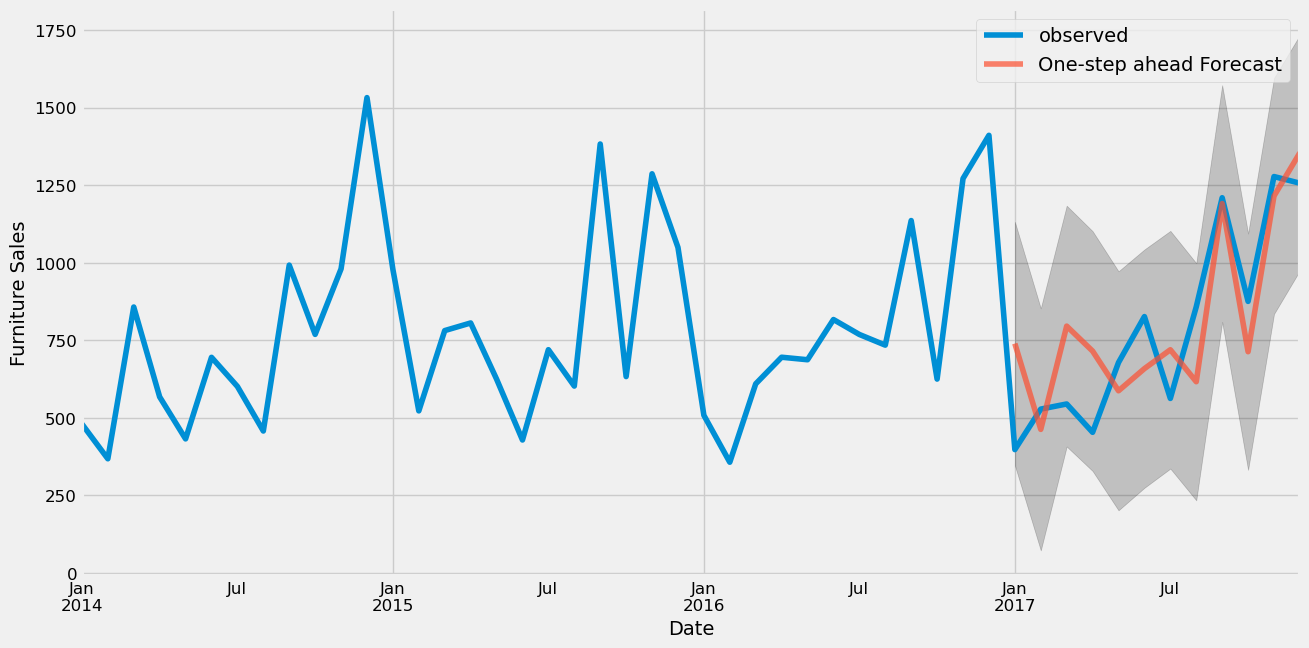

In [192]:
pred = results.get_prediction(start=pd.to_datetime('2017-01-01'), dynamic=False)
pred_ci = pred.conf_int()
ax = y['2014':].plot(label='observed')
pred.predicted_mean.plot(ax=ax, label='One-step ahead Forecast', alpha=.7, figsize=(14, 7))
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.2)
ax.set_xlabel('Date')
ax.set_ylabel('Furniture Sales')
plt.legend()
plt.show()

#### O gráfico de linha está mostrando os valores observados em comparação com as previsões de previsão contínuas. 
#### No geral, nossas previsões se alinham muito bem com os valores reais, mostrando uma tendência de alta desde o início do ano e capturando a sazonalidade no final do ano.

In [193]:
y_forecasted = pred.predicted_mean
y_truth = y['2017-01-01':]
mse = ((y_forecasted - y_truth) ** 2).mean()
print('The Mean Squared Error of our forecasts is {}'.format(round(mse, 2)))

The Mean Squared Error of our forecasts is 34370.12


#### O erro quadrático médio de nossas previsões é 34.370,12

In [194]:
print('The Root Mean Squared Error of our forecasts is {}'.format(round(np.sqrt(mse), 2)))

The Root Mean Squared Error of our forecasts is 185.39


#### A raiz do erro quadrático médio de nossas previsões é 185,39

#### Em estatística, o erro quadrático médio (MSE) de um estimador mede a média dos quadrados dos erros — ou seja, a diferença média quadrática entre os valores estimados e o que é estimado. O MSE é uma medida da qualidade de um estimador — é sempre não negativo, e quanto menor o MSE, mais perto estamos de encontrar a linha de melhor ajuste.

#### Root Mean Square Error (RMSE) nos diz que nosso modelo foi capaz de prever a média diária de vendas de móveis no conjunto de teste dentro de 185,39 das vendas reais. Nossas vendas diárias de móveis variam de cerca de 400 a mais de 1200. Na minha opinião, este é um modelo muito bom até agora.

# Produção e visualização de previsões.

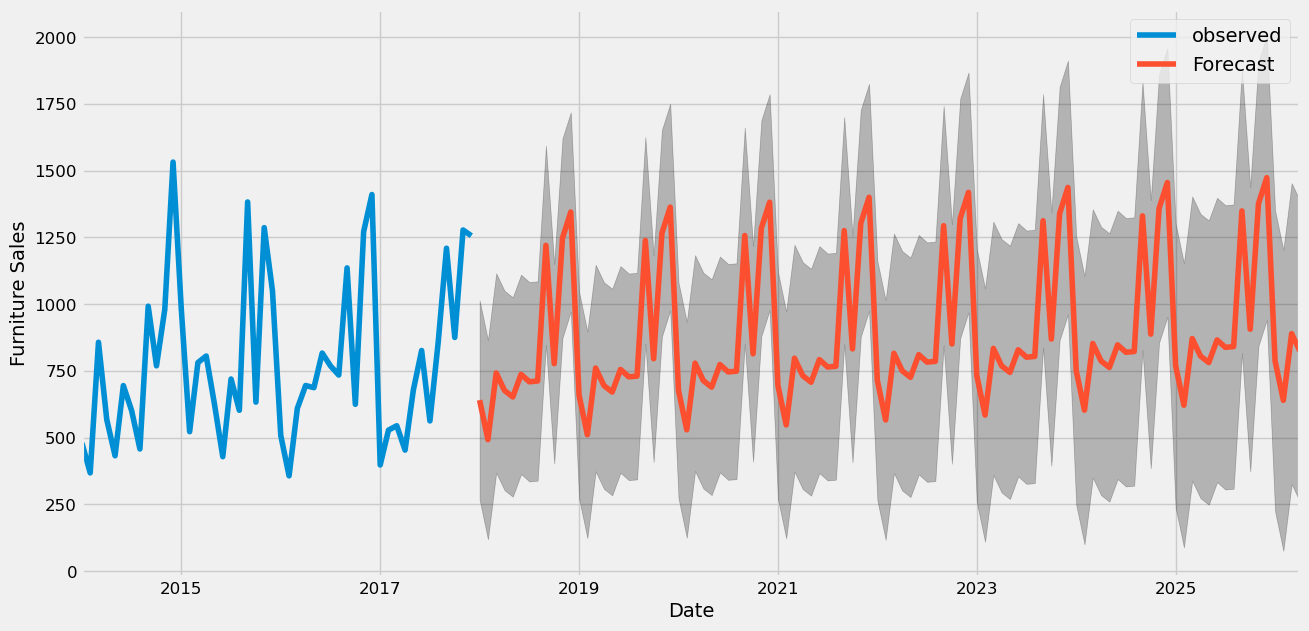

In [196]:
pred_uc = results.get_forecast(steps=100)
pred_ci = pred_uc.conf_int()
ax = y.plot(label='observed', figsize=(14, 7))
pred_uc.predicted_mean.plot(ax=ax, label='Forecast')
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.25)
ax.set_xlabel('Date')
ax.set_ylabel('Furniture Sales')
plt.legend()
plt.show()

#### Nosso modelo capturou claramente a sazonalidade das vendas de móveis. 
#### À medida que fazemos previsões para o futuro, é natural que nos tornemos menos confiantes em nossos valores. 
#### Isso se reflete nos intervalos de confiança gerados por nosso modelo, que crescem à medida que avançamos no futuro. 
#### A análise da série temporal acima para móveis me deixa curioso sobre outras categorias e como elas se comparam ao longo do tempo. 
#### Portanto, vamos comparar séries temporais de móveis e fornecedores de escritório.

# Série temporal de móveis x material de escritório.

#### Houve muito mais vendas de Materiais para Escritório do que a de Móveis ao longo dos anos.

In [197]:
furniture = df.loc[df['Category'] == 'Furniture']
office = df.loc[df['Category'] == 'Office Supplies']
furniture.shape, office.shape

((2121, 21), (6026, 21))

# Exploração de dados.

#### Comparar as vendas de duas categorias no mesmo período. 
#### Combinar dois quadros de dados em um e plotar as séries temporais dessas duas categorias em um gráfico.

In [198]:
cols = ['Row ID', 'Order ID', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Quantity', 'Discount', 'Profit']
furniture.drop(cols, axis=1, inplace=True)
office.drop(cols, axis=1, inplace=True)
furniture = furniture.sort_values('Order Date')
office = office.sort_values('Order Date')
furniture = furniture.groupby('Order Date')['Sales'].sum().reset_index()
office = office.groupby('Order Date')['Sales'].sum().reset_index()
furniture = furniture.set_index('Order Date')
office = office.set_index('Order Date')
y_furniture = furniture['Sales'].resample('MS').mean()
y_office = office['Sales'].resample('MS').mean()
furniture = pd.DataFrame({'Order Date':y_furniture.index, 'Sales':y_furniture.values})
office = pd.DataFrame({'Order Date': y_office.index, 'Sales': y_office.values})
store = furniture.merge(office, how='inner', on='Order Date')
store.rename(columns={'Sales_x': 'furniture_sales', 'Sales_y': 'office_sales'}, inplace=True)
store.head()

,Order Date,furniture_sales,office_sales
0,2014-01-01,480.194231,285.357647
1,2014-02-01,367.931600,63.042588
2,2014-03-01,857.291529,391.176318
3,2014-04-01,567.488357,464.794750
4,2014-05-01,432.049188,324.346545


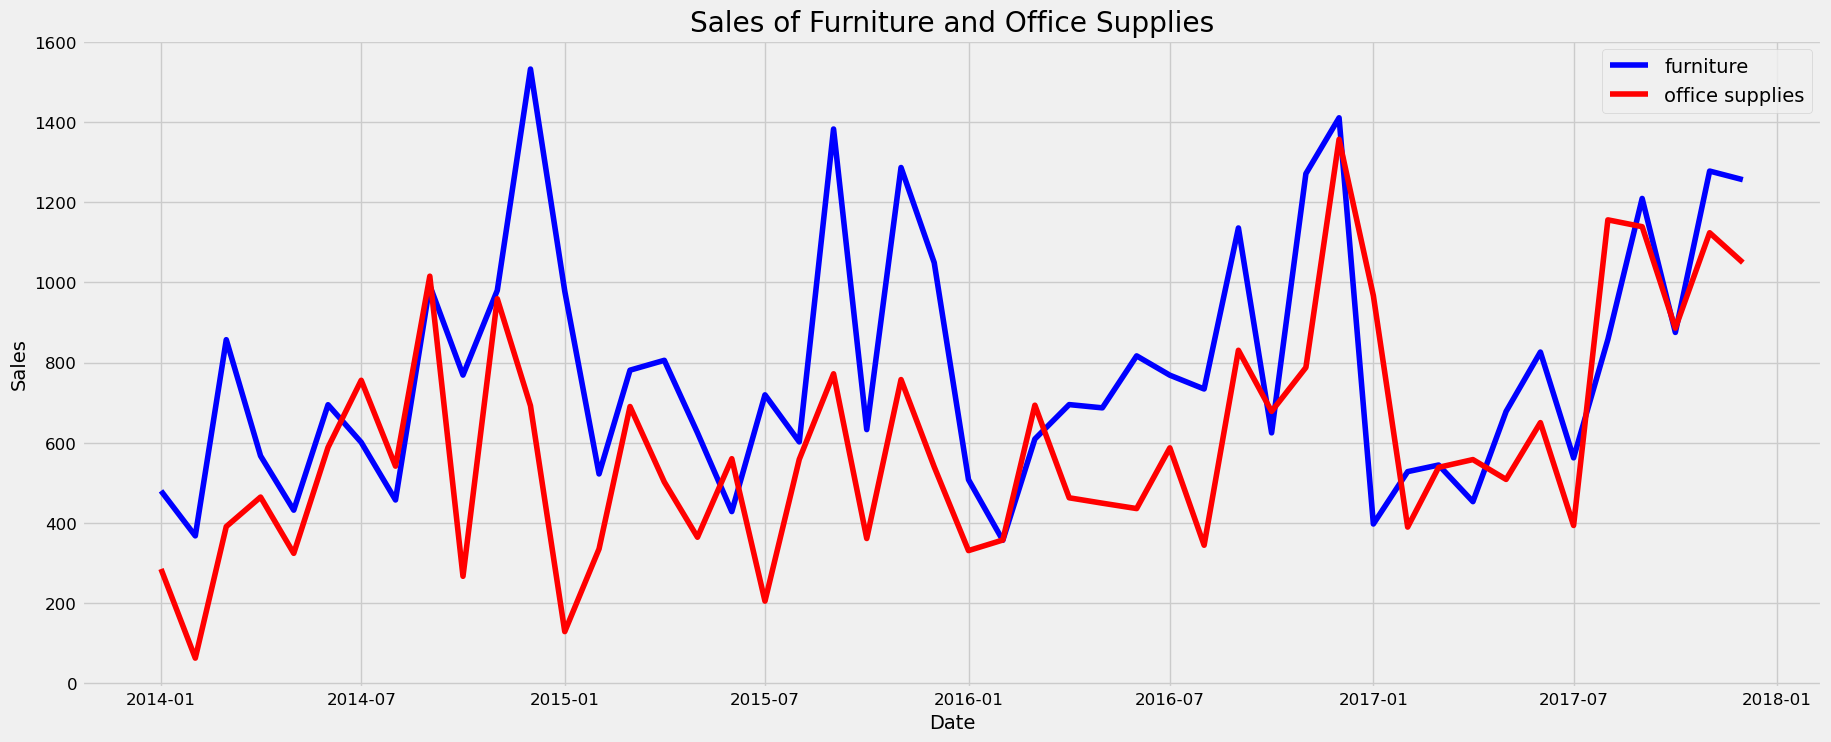

In [199]:
plt.figure(figsize=(20, 8))
plt.plot(store['Order Date'], store['furniture_sales'], 'b-', label = 'furniture')
plt.plot(store['Order Date'], store['office_sales'], 'r-', label = 'office supplies')
plt.xlabel('Date'); plt.ylabel('Sales'); plt.title('Sales of Furniture and Office Supplies')
plt.legend();

#### Observamos que as vendas de móveis e materiais de escritório apresentaram padrão sazonal semelhante. 
#### O início do ano é a baixa temporada para ambas as categorias. 
#### Parece que o horário de verão também está tranquilo para materiais de escritório. 
#### As vendas médias diárias de móveis são superiores às de materiais de escritório na maior parte dos meses. 
#### Ocasionalmente, os materiais de escritório ultrapassavam os móveis nas vendas médias diárias. 
#### Descobrir quando foi a primeira vez que as vendas de materiais de escritório superaram as de móveis.

In [200]:
first_date = store.loc[np.min(list(np.where(store['office_sales'] > store['furniture_sales'])[0])), 'Order Date']
print("Office supplies first time produced higher sales than furniture is {}.".format(first_date.date()))

Office supplies first time produced higher sales than furniture is 2014-07-01.


#### Materiais de escritório produziram pela primeira vez vendas mais altas do que móveis em 2014–07–01.

# Modelagem de séries temporais com o Prophet.

#### Lançada pelo Facebook em 2017, a ferramenta de previsão Prophet foi projetada para analisar séries temporais que exibem padrões em diferentes escalas de tempo, como anual, semanal e diário. 
#### Ele também possui recursos avançados para modelar os efeitos dos feriados em uma série temporal e implementar pontos de mudança personalizados. 
#### Portanto, estamos usando o Prophet para colocar um modelo em funcionamento.

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1


<Figure size 1800x600 with 0 Axes>

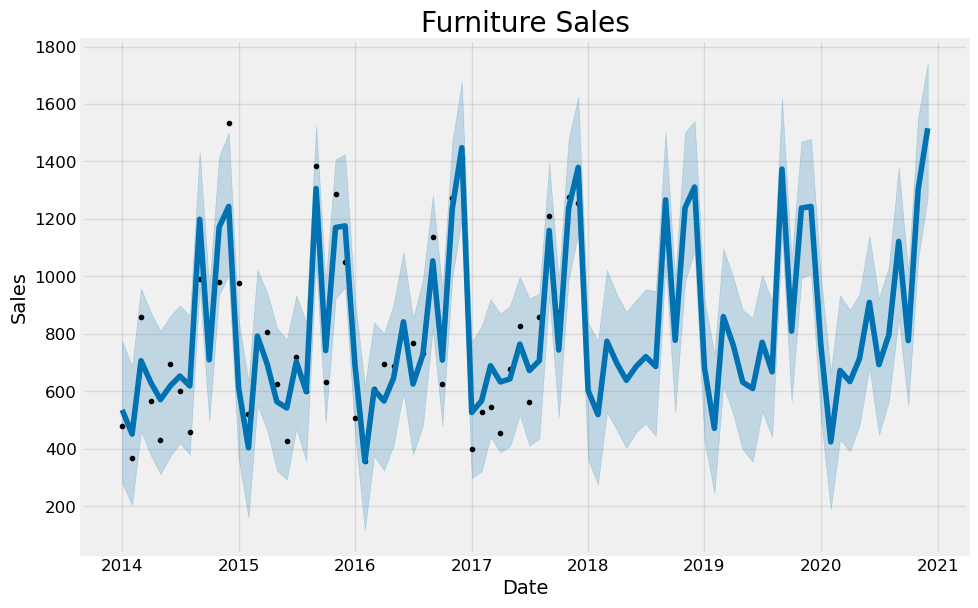

In [202]:
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')
furniture = furniture.rename(columns={'Order Date': 'ds', 'Sales': 'y'})
furniture_model = Prophet(interval_width=0.95)
furniture_model.fit(furniture)
office = office.rename(columns={'Order Date': 'ds', 'Sales': 'y'})
office_model = Prophet(interval_width=0.95)
office_model.fit(office)
furniture_forecast = furniture_model.make_future_dataframe(periods=36, freq='MS')
furniture_forecast = furniture_model.predict(furniture_forecast)
office_forecast = office_model.make_future_dataframe(periods=36, freq='MS')
office_forecast = office_model.predict(office_forecast)
plt.figure(figsize=(18, 6))
furniture_model.plot(furniture_forecast, xlabel = 'Date', ylabel = 'Sales')
plt.title('Furniture Sales');

<Figure size 1800x600 with 0 Axes>

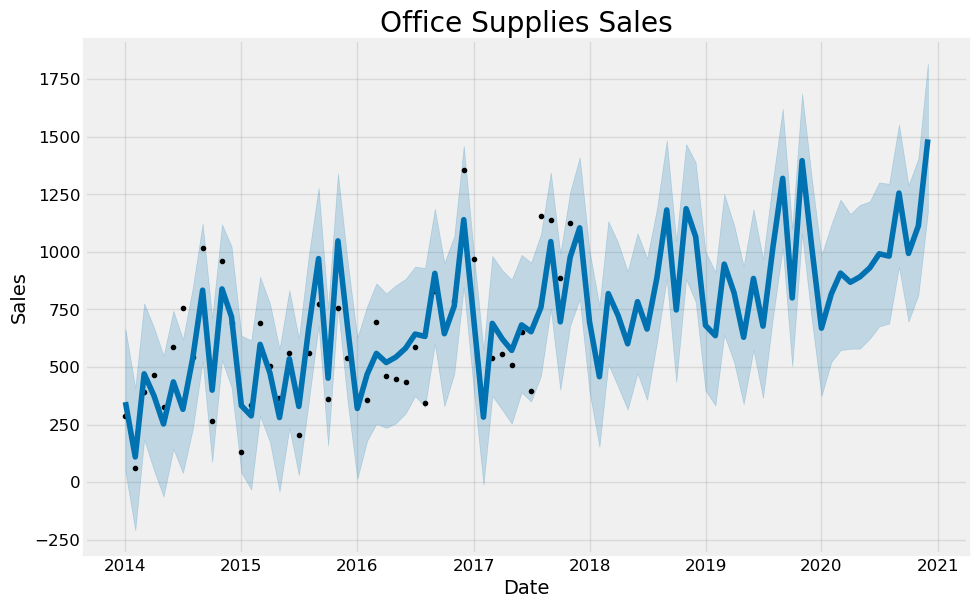

In [203]:
plt.figure(figsize=(18, 6))
office_model.plot(office_forecast, xlabel = 'Date', ylabel = 'Sales')
plt.title('Office Supplies Sales');

# Comparar previsões.

#### Já temos as projeções para três anos dessas duas categorias no futuro. 

#### Vamos agora juntá-los para comparar suas previsões futuras.

In [205]:
furniture_names = ['furniture_%s' % column for column in furniture_forecast.columns]
office_names = ['office_%s' % column for column in office_forecast.columns]
merge_furniture_forecast = furniture_forecast.copy()
merge_office_forecast = office_forecast.copy()
merge_furniture_forecast.columns = furniture_names
merge_office_forecast.columns = office_names
forecast = pd.merge(merge_furniture_forecast, merge_office_forecast, how = 'inner', left_on = 'furniture_ds', right_on = 'office_ds')
forecast = forecast.rename(columns={'furniture_ds': 'Date'}).drop('office_ds', axis=1)
forecast.head()

,Date,furniture_trend,furniture_yhat_lower,furniture_yhat_upper,furniture_trend_lower,furniture_trend_upper,furniture_additive_terms,furniture_additive_terms_lower,furniture_additive_terms_upper,furniture_yearly,...,office_additive_terms,office_additive_terms_lower,office_additive_terms_upper,office_yearly,office_yearly_lower,office_yearly_upper,office_multiplicative_terms,office_multiplicative_terms_lower,office_multiplicative_terms_upper,office_yhat
0,2014-01-01,726.058109,279.363682,774.540501,726.058109,726.058109,-190.686099,-190.686099,-190.686099,-190.686099,...,-140.041115,-140.041115,-140.041115,-140.041115,-140.041115,-140.041115,0.0,0.0,0.0,347.489370
1,2014-02-01,727.494421,204.324101,686.103183,727.494421,727.494421,-276.379157,-276.379157,-276.379157,-276.379157,...,-385.677761,-385.677761,-385.677761,-385.677761,-385.677761,-385.677761,0.0,0.0,0.0,109.240405
2,2014-03-01,728.791734,462.078697,957.987119,728.791734,728.791734,-22.388253,-22.388253,-22.388253,-22.388253,...,-31.378526,-31.378526,-31.378526,-31.378526,-31.378526,-31.378526,0.0,0.0,0.0,470.212385
3,2014-04-01,730.228046,376.890508,873.903704,730.228046,730.228046,-100.140909,-100.140909,-100.140909,-100.140909,...,-134.290665,-134.290665,-134.290665,-134.290665,-134.290665,-134.290665,0.0,0.0,0.0,374.687928
4,2014-05-01,731.618025,311.951006,810.073909,731.618025,731.618025,-160.818882,-160.818882,-160.818882,-160.818882,...,-263.823552,-263.823552,-263.823552,-263.823552,-263.823552,-263.823552,0.0,0.0,0.0,252.304409


#### Visualização de tendências e previsões.

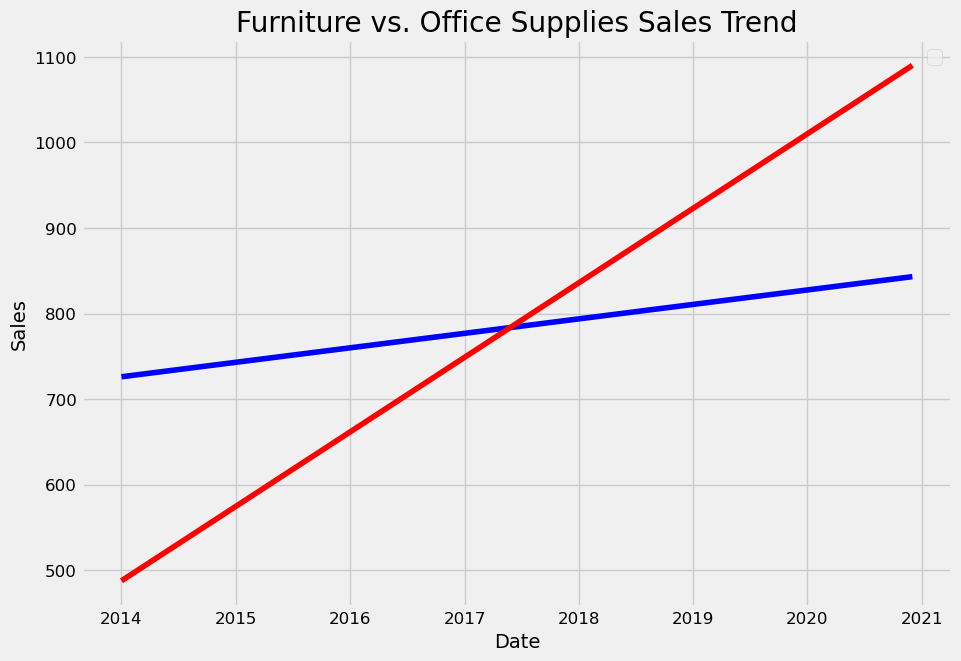

In [207]:
plt.figure(figsize=(10, 7))
plt.plot(forecast['Date'], forecast['furniture_trend'], 'b-')
plt.plot(forecast['Date'], forecast['office_trend'], 'r-')
plt.legend(); plt.xlabel('Date'); plt.ylabel('Sales')
plt.title('Furniture vs. Office Supplies Sales Trend');

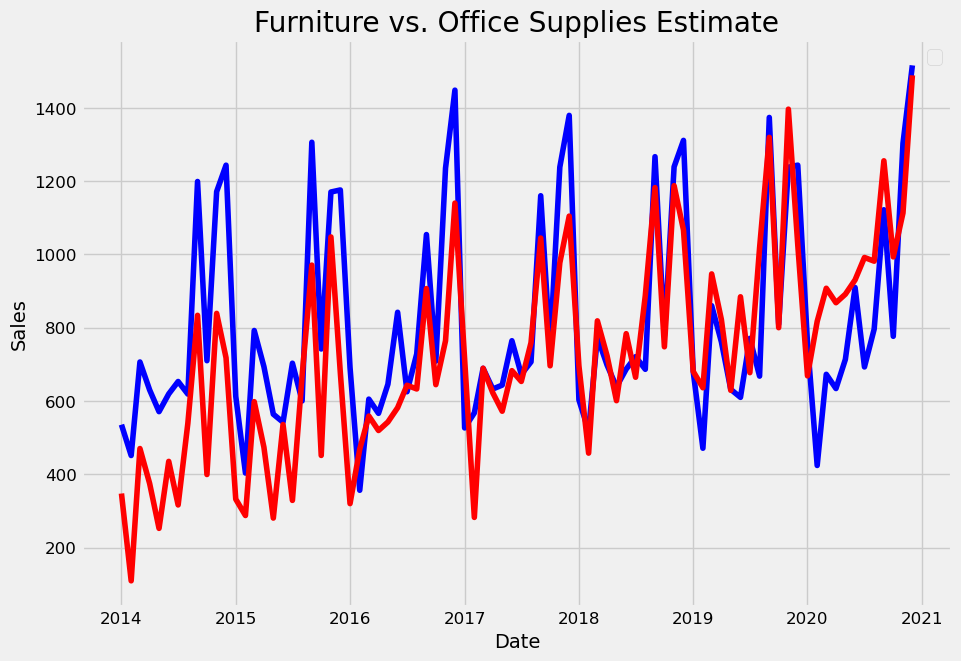

In [208]:
plt.figure(figsize=(10, 7))
plt.plot(forecast['Date'], forecast['furniture_yhat'], 'b-')
plt.plot(forecast['Date'], forecast['office_yhat'], 'r-')
plt.legend(); plt.xlabel('Date'); plt.ylabel('Sales')
plt.title('Furniture vs. Office Supplies Estimate');

# Tendências e Padrões.

In [ ]:
##Agora, podemos usar os Modelos do Prophet para inspecionar diferentes tendências dessas duas categorias nos dados.

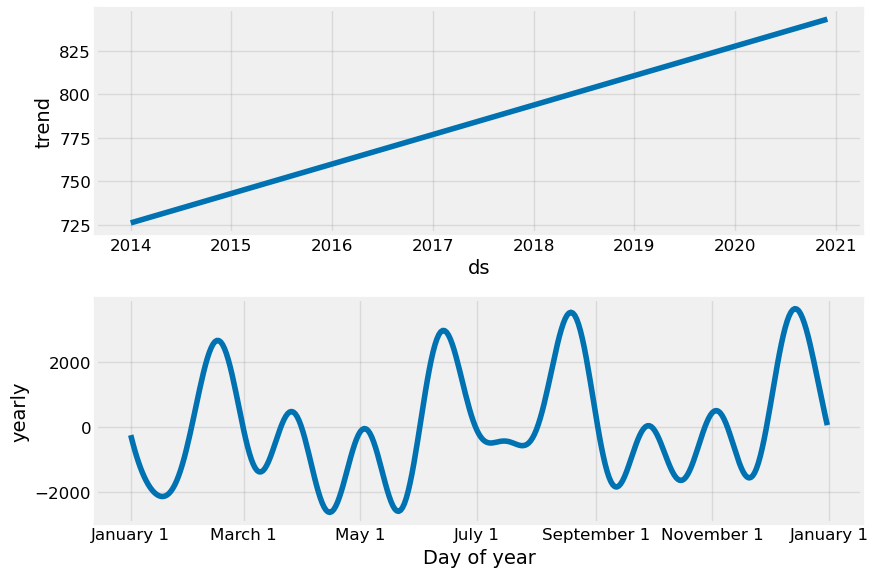

In [210]:
furniture_model.plot_components(furniture_forecast);

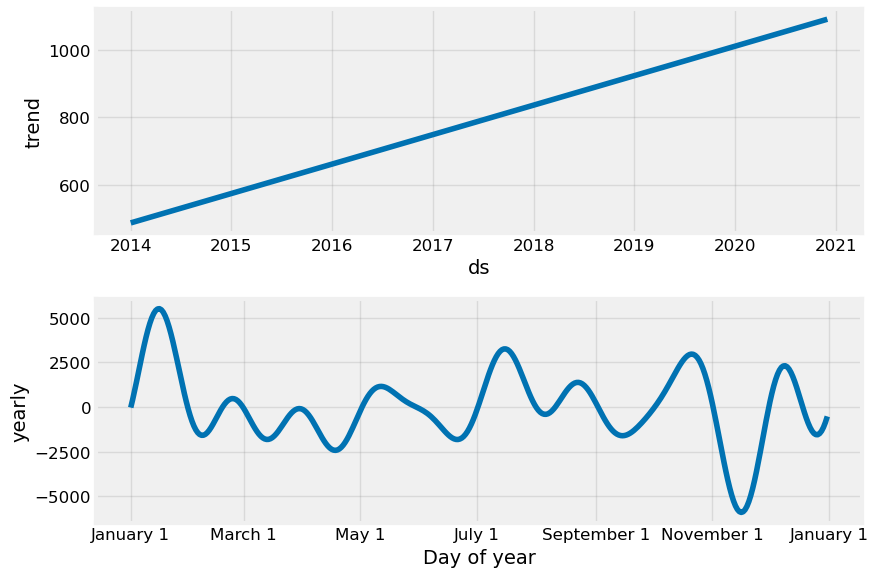

In [211]:
office_model.plot_components(office_forecast);

# Considerações:

#### É bom ver que as vendas de móveis e materiais de escritório têm aumentado linearmente ao longo do tempo e continuarão crescendo, embora o crescimento dos materiais de escritório pareça um pouco mais forte. 
#### O pior mês para móveis é abril, o pior mês para material de escritório é fevereiro. 
#### O melhor mês para móveis é dezembro e o melhor mês para materiais de escritório é outubro. 
#### Existem muitas análises de séries temporais que podemos explorar a partir de agora, como previsão com limites de incerteza, ponto de mudança e detecção de anomalias.
 

###### Crédito: https://towardsdatascience.com/an-end-to-end-project-on-time-series-analysis-and-forecasting-with-python-4835e6bf050b
###### O código possuia bibliotecas desatualizadas e alguns erros de sintaxe (alteração de nomenclaturas, devido o passar dos anos).